In [ ]:
# Import all needed libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D, Flatten, Dense

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Download MNIST Datasets
(X_train, y_train),(X_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Precprocess dataset
X_train = X_train.reshape((-1,28,28,1))/255.0
X_test = X_test.reshape((-1,28,28,1))/255.0
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [5]:
# Build the CNN model
model = Sequential([
    Conv2D(32,(3, 3), activation = 'relu', input_shape = (28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation = 'relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation = 'relu'),
    Dense(10, activation = 'softmax')
])

c:\Users\marth\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile and train the model
model.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train,y_train, batch_size=128, epochs=10,validation_data=(X_test,y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.8357 - loss: 0.5479 - val_accuracy: 0.9786 - val_loss: 0.0636
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9794 - loss: 0.0690 - val_accuracy: 0.9868 - val_loss: 0.0401
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9863 - loss: 0.0478 - val_accuracy: 0.9856 - val_loss: 0.0400
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9896 - loss: 0.0351 - val_accuracy: 0.9892 - val_loss: 0.0297
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9911 - loss: 0.0276 - val_accuracy: 0.9888 - val_loss: 0.0321
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9933 - loss: 0.0218 - val_accuracy: 0.9903 - val_loss: 0.0287
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9946 - loss: 0.0171 - val_accuracy: 0.9899 - val_loss: 0.0310
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9957 - loss: 0.0143 - 

In [7]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test,y_test)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9871 - loss: 0.0376
Test Loss: 0.0325
Test Accuracy: 0.9893


In [ ]:
# Select random images from the test
random_indexes = np.random.choice(len(X_test), size = 5, replace=False)
images = X_test[random_indexes]
true_labels = np.argmax(y_test[random_indexes], axis=1)

In [ ]:
# Make predictions using the trained model
predictions = np.argmax(model.predict(images), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

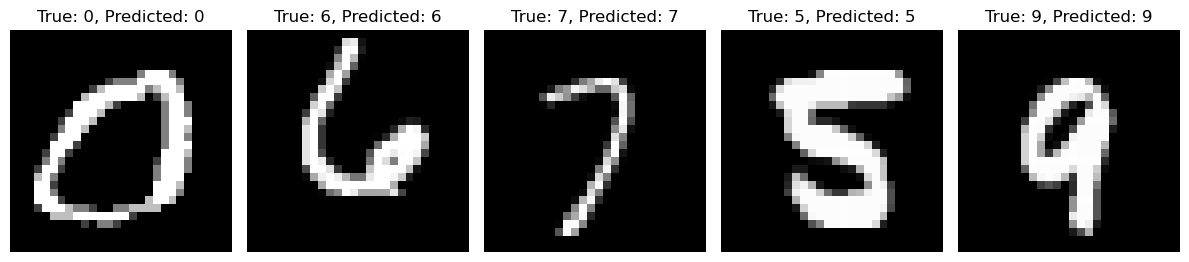

In [11]:
# Depict images, their model predictions and their true label
fig, axes = plt.subplots(1,5, figsize=(12,4))
for i, (image,true_label,predicted_label) in enumerate(zip(images, true_labels, predictions)):
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f'True: {true_label}, Predicted: {predicted_label}')
    axes[i].axis('off')
    
plt.tight_layout()
plt.show